In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
## Load the dataset
DATASET_PATH = "dataset/UCI HAR Dataset"
print(os.listdir(DATASET_PATH))
activity_labels = pd.read_csv(
    f"{DATASET_PATH}/activity_labels.txt",
    sep=" ",
    header=None,
    names=["Activity_ID", "Activity"]
)

activity_labels

['.DS_Store', 'activity_labels.txt', 'features.txt', 'features_info.txt', 'README.txt', 'test', 'train']


,Activity_ID,Activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


In [ ]:
# load features
features = pd.read_csv(
    f"{DATASET_PATH}/features.txt",
    sep=r"\s+",
    header=None,
    names=["Feature_ID", "Feature"]
)

print(features.head())
print("Number of features:", len(features))

   Feature_ID            Feature
0           1  tBodyAcc-mean()-X
1           2  tBodyAcc-mean()-Y
2           3  tBodyAcc-mean()-Z
3           4   tBodyAcc-std()-X
4           5   tBodyAcc-std()-Y
Number of features: 561


In [ ]:
# load training data
X_train = pd.read_csv(
    f"{DATASET_PATH}/train/X_train.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    f"{DATASET_PATH}/train/y_train.txt",
    sep=r"\s+",
    header=None,
    names=["Activity_ID"]
)

subject_train = pd.read_csv(
    f"{DATASET_PATH}/train/subject_train.txt",
    sep=r"\s+",
    header=None,
    names=["Subject"]
)

In [6]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("subject_train shape:", subject_train.shape)

X_train shape: (7352, 561)
y_train shape: (7352, 1)
subject_train shape: (7352, 1)


In [ ]:
#load testing data
X_test = pd.read_csv(
    f"{DATASET_PATH}/test/X_test.txt",
    sep=r"\s+",
    header=None
)

y_test = pd.read_csv(
    f"{DATASET_PATH}/test/y_test.txt",
    sep=r"\s+",
    header=None,
    names=["Activity_ID"]
)

subject_test = pd.read_csv(
    f"{DATASET_PATH}/test/subject_test.txt",
    sep=r"\s+",
    header=None,
    names=["Subject"]
)

In [9]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("subject_test shape:", subject_test.shape)

X_test shape: (2947, 561)
y_test shape: (2947, 1)
subject_test shape: (2947, 1)


In [ ]:
#label coloumns with feature names
X_train.columns = features["Feature"].values
X_test.columns = features["Feature"].values

In [11]:
X_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [ ]:
#label activities with descriptive names
activity_dict = dict(
    zip(
        activity_labels["Activity_ID"],
        activity_labels["Activity"]
    )
)
y_train["Activity"] = y_train["Activity_ID"].map(activity_dict)
y_test["Activity"] = y_test["Activity_ID"].map(activity_dict)

In [13]:
y_train.head()

,Activity_ID,Activity
0,5,STANDING
1,5,STANDING
2,5,STANDING
3,5,STANDING
4,5,STANDING


In [ ]:
#check missing values
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())
print("Missing values in y_train:", y_train.isnull().sum().sum())
print("Missing values in y_test:", y_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0
Missing values in y_test: 0


In [ ]:
#check duplicate records
print("Duplicate rows in X_train:", X_train.duplicated().sum())
print("Duplicate rows in X_test:", X_test.duplicated().sum())

Duplicate rows in X_train: 0
Duplicate rows in X_test: 0


In [16]:
#check data types
print(X_train.dtypes.value_counts())

float64    561
Name: count, dtype: int64


Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


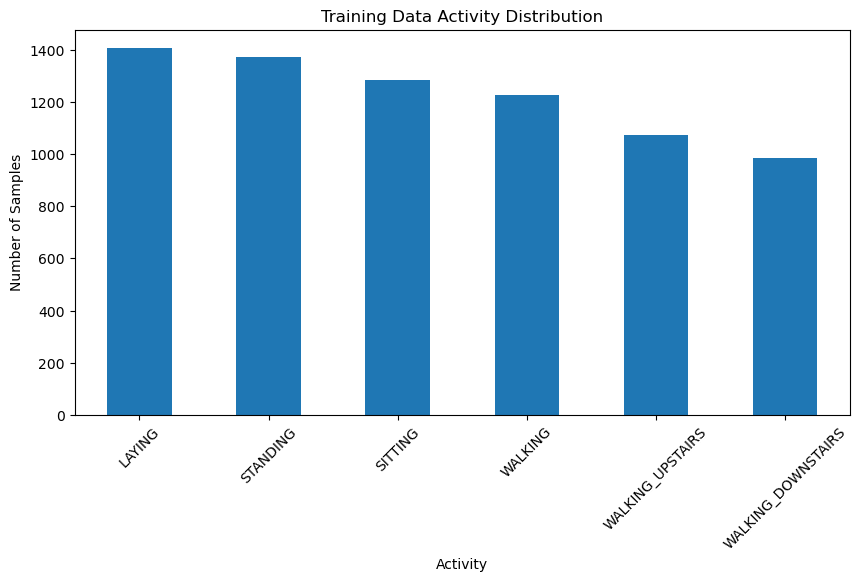

In [17]:
#check the distribution of activities in the training and testing sets
activity_counts = y_train["Activity"].value_counts()
print(activity_counts)

plt.figure(figsize=(10, 5))

activity_counts.plot(kind="bar")

plt.title("Training Data Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.show()

In [18]:
# check actual sensor data 
X_train.head()


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [ ]:
#data preprocessing


In [19]:
#Check the labels carefully
print("Training activity IDs:")
print(sorted(y_train["Activity_ID"].unique()))

print("\nTesting activity IDs:")
print(sorted(y_test["Activity_ID"].unique()))

print("\nActivity mapping:")
print(activity_dict)

Training activity IDs:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Testing activity IDs:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Activity mapping:
{1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}


In [20]:
#check for invalid numric values 
print("Infinite values in X_train:",
      np.isinf(X_train.select_dtypes(include=np.number)).sum().sum())

print("Infinite values in X_test:",
      np.isinf(X_test.select_dtypes(include=np.number)).sum().sum())

Infinite values in X_train: 0
Infinite values in X_test: 0


In [21]:
#check feature ranges
print("Minimum feature value:", X_train.min().min())
print("Maximum feature value:", X_train.max().max())

Minimum feature value: -1.0
Maximum feature value: 1.0


In [22]:
#Check whether the number of features matches
print("Number of feature names:", len(features))
print("Number of X_train columns:", X_train.shape[1])
print("Number of X_test columns:", X_test.shape[1])


Number of feature names: 561
Number of X_train columns: 561
Number of X_test columns: 561


In [23]:
#check for duplicate feature name
duplicate_features = features["Feature"].duplicated().sum()

print("Duplicate feature names:", duplicate_features)

Duplicate feature names: 84


In [25]:
#Create the final labels
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

y_train_clean = y_train["Activity_ID"].copy()
y_test_clean = y_test["Activity_ID"].copy()
print("X_train:", X_train_clean.shape)
print("y_train:", y_train_clean.shape)

print("X_test:", X_test_clean.shape)
print("y_test:", y_test_clean.shape)

X_train: (7352, 561)
y_train: (7352,)
X_test: (2947, 561)
y_test: (2947,)


In [26]:
#Check that every X has a corresponding y
print("Training samples:", len(X_train_clean))
print("Training labels:", len(y_train_clean))

print("Testing samples:", len(X_test_clean))
print("Testing labels:", len(y_test_clean))


Training samples: 7352
Training labels: 7352
Testing samples: 2947
Testing labels: 2947


In [27]:
#Check the final activity distribution
print("Training data:")
print(y_train_clean.map(activity_dict).value_counts())

print("\nTesting data:")
print(y_test_clean.map(activity_dict).value_counts())


Training data:
Activity_ID
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

Testing data:
Activity_ID
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64


In [28]:
#inspection of the final data
sample_data = X_train_clean.copy()

sample_data["Activity_ID"] = y_train_clean.values
sample_data["Activity"] = y_train_clean.map(activity_dict).values

sample_data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity_ID,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5,STANDING


In [29]:
duplicate_features = features[features["Feature"].duplicated(keep=False)]

print("Number of duplicated feature-name rows:", len(duplicate_features))
print("Number of unique duplicated feature names:",
      duplicate_features["Feature"].nunique())

duplicate_features.sort_values("Feature").head(30)


Number of duplicated feature-name rows: 126
Number of unique duplicated feature names: 42


,Feature_ID,Feature
338,339,"fBodyAcc-bandsEnergy()-1,16"
324,325,"fBodyAcc-bandsEnergy()-1,16"
310,311,"fBodyAcc-bandsEnergy()-1,16"
342,343,"fBodyAcc-bandsEnergy()-1,24"
328,329,"fBodyAcc-bandsEnergy()-1,24"
314,315,"fBodyAcc-bandsEnergy()-1,24"
330,331,"fBodyAcc-bandsEnergy()-1,8"
316,317,"fBodyAcc-bandsEnergy()-1,8"
302,303,"fBodyAcc-bandsEnergy()-1,8"
332,333,"fBodyAcc-bandsEnergy()-17,24"


In [30]:
feature_counts = features["Feature"].value_counts()

feature_counts[feature_counts > 1]

Feature
fBodyAccJerk-bandsEnergy()-41,48    3
fBodyAcc-bandsEnergy()-57,64        3
fBodyAcc-bandsEnergy()-41,48        3
fBodyAcc-bandsEnergy()-33,40        3
fBodyAcc-bandsEnergy()-25,32        3
fBodyAcc-bandsEnergy()-17,24        3
fBodyAcc-bandsEnergy()-9,16         3
fBodyAcc-bandsEnergy()-1,8          3
fBodyGyro-bandsEnergy()-1,8         3
fBodyGyro-bandsEnergy()-9,16        3
fBodyGyro-bandsEnergy()-17,24       3
fBodyGyro-bandsEnergy()-25,32       3
fBodyGyro-bandsEnergy()-33,40       3
fBodyGyro-bandsEnergy()-41,48       3
fBodyGyro-bandsEnergy()-49,56       3
fBodyGyro-bandsEnergy()-1,16        3
fBodyGyro-bandsEnergy()-17,32       3
fBodyGyro-bandsEnergy()-33,48       3
fBodyGyro-bandsEnergy()-49,64       3
fBodyAcc-bandsEnergy()-49,56        3
fBodyAcc-bandsEnergy()-1,16         3
fBodyGyro-bandsEnergy()-25,48       3
fBodyAcc-bandsEnergy()-17,32        3
fBodyAccJerk-bandsEnergy()-1,8      3
fBodyAccJerk-bandsEnergy()-9,16     3
fBodyAccJerk-bandsEnergy()-17,24    3
fBod

In [31]:
# Check for completely identical feature columns

duplicate_data_columns = X_train_clean.T.duplicated().sum()

print("Completely identical feature columns:", duplicate_data_columns)

Completely identical feature columns: 21


In [32]:
print("Total feature columns:", X_train_clean.shape[1])
print("Total feature names:", len(features))

print("Feature names are unique:",
      features["Feature"].is_unique)

Total feature columns: 561
Total feature names: 561
Feature names are unique: False


In [33]:
duplicate_data_columns = X_train_clean.T.duplicated().sum()

print("Completely identical feature columns:", duplicate_data_columns)

Completely identical feature columns: 21


In [34]:
print("Total feature columns:", X_train_clean.shape[1])
print("Total feature names:", len(features))
print("Feature names are unique:",
      features["Feature"].is_unique)


Total feature columns: 561
Total feature names: 561
Feature names are unique: False


In [35]:
# Find completely identical feature columns

duplicate_columns = X_train_clean.columns[
    X_train_clean.T.duplicated()
]

print("Number of duplicate data columns:", len(duplicate_columns))
print("\nDuplicate columns:")
for col in duplicate_columns:
    print(col)

Number of duplicate data columns: 21

Duplicate columns:
tBodyAccMag-sma()
tGravityAccMag-mean()
tGravityAccMag-std()
tGravityAccMag-mad()
tGravityAccMag-max()
tGravityAccMag-min()
tGravityAccMag-sma()
tGravityAccMag-energy()
tGravityAccMag-iqr()
tGravityAccMag-entropy()
tGravityAccMag-arCoeff()1
tGravityAccMag-arCoeff()2
tGravityAccMag-arCoeff()3
tGravityAccMag-arCoeff()4
tBodyAccJerkMag-sma()
tBodyGyroMag-sma()
tBodyGyroJerkMag-sma()
fBodyAccMag-sma()
fBodyBodyAccJerkMag-sma()
fBodyBodyGyroMag-sma()
fBodyBodyGyroJerkMag-sma()


In [36]:
duplicate_columns = X_train_clean.columns[
    X_train_clean.T.duplicated()
]

print("Checking the same 21 columns in X_test...\n")

for col in duplicate_columns:
    matching_columns = [
        other_col for other_col in X_test_clean.columns
        if X_test_clean[col].equals(X_test_clean[other_col])
        and other_col != col
    ]
    
    if matching_columns:
        print(f"{col} → duplicate of {matching_columns}")

Checking the same 21 columns in X_test...

tBodyAccMag-sma() → duplicate of ['tBodyAccMag-mean()', 'tGravityAccMag-mean()', 'tGravityAccMag-sma()']
tGravityAccMag-mean() → duplicate of ['tBodyAccMag-mean()', 'tBodyAccMag-sma()', 'tGravityAccMag-sma()']
tGravityAccMag-std() → duplicate of ['tBodyAccMag-std()']
tGravityAccMag-mad() → duplicate of ['tBodyAccMag-mad()']
tGravityAccMag-max() → duplicate of ['tBodyAccMag-max()']
tGravityAccMag-min() → duplicate of ['tBodyAccMag-min()']
tGravityAccMag-sma() → duplicate of ['tBodyAccMag-mean()', 'tBodyAccMag-sma()', 'tGravityAccMag-mean()']
tGravityAccMag-energy() → duplicate of ['tBodyAccMag-energy()']
tGravityAccMag-iqr() → duplicate of ['tBodyAccMag-iqr()']
tGravityAccMag-entropy() → duplicate of ['tBodyAccMag-entropy()']
tGravityAccMag-arCoeff()1 → duplicate of ['tBodyAccMag-arCoeff()1']
tGravityAccMag-arCoeff()2 → duplicate of ['tBodyAccMag-arCoeff()2']
tGravityAccMag-arCoeff()3 → duplicate of ['tBodyAccMag-arCoeff()3']
tGravityAccMag-arC

In [37]:
#creatre unique feature names by appending suffixes to duplicates
feature_names = features["Feature"].tolist()
from collections import Counter

name_counter = Counter()
unique_feature_names = []

for name in feature_names:
    name_counter[name] += 1
    
    if name_counter[name] == 1:
        unique_feature_names.append(name)
    else:
        unique_feature_names.append(
            f"{name}_{name_counter[name]}"
        )

print("Original feature names:", len(feature_names))
print("Unique feature names:", len(set(unique_feature_names)))

Original feature names: 561
Unique feature names: 561


In [38]:
X_train_clean.columns = unique_feature_names
X_test_clean.columns = unique_feature_names

In [39]:
print("Training columns:", X_train_clean.shape[1])
print("Testing columns:", X_test_clean.shape[1])

print("Training column names unique:",
      X_train_clean.columns.is_unique)

print("Testing column names unique:",
      X_test_clean.columns.is_unique)

Training columns: 561
Testing columns: 561
Training column names unique: True
Testing column names unique: True


In [40]:
for i, name in enumerate(unique_feature_names):
    if name.endswith("_2") or name.endswith("_3"):
        print(i + 1, name)

317 fBodyAcc-bandsEnergy()-1,8_2
318 fBodyAcc-bandsEnergy()-9,16_2
319 fBodyAcc-bandsEnergy()-17,24_2
320 fBodyAcc-bandsEnergy()-25,32_2
321 fBodyAcc-bandsEnergy()-33,40_2
322 fBodyAcc-bandsEnergy()-41,48_2
323 fBodyAcc-bandsEnergy()-49,56_2
324 fBodyAcc-bandsEnergy()-57,64_2
325 fBodyAcc-bandsEnergy()-1,16_2
326 fBodyAcc-bandsEnergy()-17,32_2
327 fBodyAcc-bandsEnergy()-33,48_2
328 fBodyAcc-bandsEnergy()-49,64_2
329 fBodyAcc-bandsEnergy()-1,24_2
330 fBodyAcc-bandsEnergy()-25,48_2
331 fBodyAcc-bandsEnergy()-1,8_3
332 fBodyAcc-bandsEnergy()-9,16_3
333 fBodyAcc-bandsEnergy()-17,24_3
334 fBodyAcc-bandsEnergy()-25,32_3
335 fBodyAcc-bandsEnergy()-33,40_3
336 fBodyAcc-bandsEnergy()-41,48_3
337 fBodyAcc-bandsEnergy()-49,56_3
338 fBodyAcc-bandsEnergy()-57,64_3
339 fBodyAcc-bandsEnergy()-1,16_3
340 fBodyAcc-bandsEnergy()-17,32_3
341 fBodyAcc-bandsEnergy()-33,48_3
342 fBodyAcc-bandsEnergy()-49,64_3
343 fBodyAcc-bandsEnergy()-1,24_3
344 fBodyAcc-bandsEnergy()-25,48_3
396 fBodyAccJerk-bandsEnergy()

In [41]:
#final check of the cleaned data
print("Final X_train shape:", X_train_clean.shape)
print("Final X_test shape:", X_test_clean.shape)

print("Final y_train shape:", y_train_clean.shape)
print("Final y_test shape:", y_test_clean.shape)

print("\nMissing values:")
print("X_train:", X_train_clean.isnull().sum().sum())
print("X_test:", X_test_clean.isnull().sum().sum())

print("\nInfinite values:")
print("X_train:", np.isinf(X_train_clean).sum().sum())
print("X_test:", np.isinf(X_test_clean).sum().sum())

print("\nUnique column names:")
print("X_train:", X_train_clean.columns.is_unique)
print("X_test:", X_test_clean.columns.is_unique)

Final X_train shape: (7352, 561)
Final X_test shape: (2947, 561)
Final y_train shape: (7352,)
Final y_test shape: (2947,)

Missing values:
X_train: 0
X_test: 0

Infinite values:
X_train: 0
X_test: 0

Unique column names:
X_train: True
X_test: True


In [42]:
processed_path = "dataset/processed"

os.makedirs(processed_path, exist_ok=True)

X_train_clean.to_csv(
    f"{processed_path}/X_train.csv",
    index=False
)

y_train_clean.to_csv(
    f"{processed_path}/y_train.csv",
    index=False
)

X_test_clean.to_csv(
    f"{processed_path}/X_test.csv",
    index=False
)

y_test_clean.to_csv(
    f"{processed_path}/y_test.csv",
    index=False
)

print("Processed datasets saved successfully!")

Processed datasets saved successfully!


In [43]:
print(os.listdir(processed_path))

['X_test.csv', 'X_train.csv', 'y_test.csv', 'y_train.csv']


In [44]:
X_train_check = pd.read_csv(
    f"{processed_path}/X_train.csv"
)

y_train_check = pd.read_csv(
    f"{processed_path}/y_train.csv"
)

X_test_check = pd.read_csv(
    f"{processed_path}/X_test.csv"
)

y_test_check = pd.read_csv(
    f"{processed_path}/y_test.csv"
)

In [45]:
print("X_train:", X_train_check.shape)
print("y_train:", y_train_check.shape)
print("X_test:", X_test_check.shape)
print("y_test:", y_test_check.shape)

X_train: (7352, 561)
y_train: (7352, 1)
X_test: (2947, 561)
y_test: (2947, 1)


In [46]:
print(
    "X_train identical:",
    X_train_clean.equals(X_train_check)
)

print(
    "X_test identical:",
    X_test_clean.equals(X_test_check)
)

print(
    "y_train identical:",
    y_train_clean.equals(y_train_check["Activity_ID"])
)

print(
    "y_test identical:",
    y_test_clean.equals(y_test_check["Activity_ID"])
)

X_train identical: True
X_test identical: True
y_train identical: True
y_test identical: True


In [47]:
dataset_summary = {
    "Total samples": len(X_train_clean) + len(X_test_clean),
    "Training samples": len(X_train_clean),
    "Testing samples": len(X_test_clean),
    "Number of features": X_train_clean.shape[1],
    "Number of activities": y_train_clean.nunique(),
    "Missing values": X_train_clean.isnull().sum().sum(),
    "Infinite values": np.isinf(X_train_clean).sum().sum()
}

for key, value in dataset_summary.items():
    print(f"{key}: {value}")

Total samples: 10299
Training samples: 7352
Testing samples: 2947
Number of features: 561
Number of activities: 6
Missing values: 0
Infinite values: 0


In [48]:
activity_summary = pd.DataFrame({
    "Activity_ID": sorted(activity_dict.keys()),
    "Activity": [
        activity_dict[i]
        for i in sorted(activity_dict.keys())
    ]
})

activity_summary

,Activity_ID,Activity
0,1,WALKING
1,2,WALKING_UPSTAIRS
2,3,WALKING_DOWNSTAIRS
3,4,SITTING
4,5,STANDING
5,6,LAYING


## Data Preprocessing Summary

The UCI Human Activity Recognition Using Smartphones dataset was used for this project.

The original dataset contains 10,299 samples and 561 sensor-derived features. The dataset provides predefined training and testing subsets.

### Preprocessing performed:

1. Loaded the training and testing datasets.
2. Loaded and assigned the original feature names.
3. Mapped activity IDs to their corresponding activity names.
4. Checked the dataset dimensions and feature counts.
5. Checked for missing values.
6. Checked for infinite values.
7. Checked for duplicate records.
8. Investigated duplicate feature names.
9. Identified 21 completely identical feature columns.
10. Retained the original 561 features to preserve the original dataset representation.
11. Made feature names unique without changing feature values.
12. Verified that every input sample has a corresponding activity label.
13. Preserved the original training/testing split.
14. Saved the prepared datasets as CSV files for machine-learning model development.

In [49]:
print("=" * 50)
print("MEMBER 1 (AKSHAY PRATAP SINGH 25BCE10184)- FINAL DATASET VERIFICATION")
print("=" * 50)

print("\nTraining Data:")
print("X_train:", X_train_clean.shape)
print("y_train:", y_train_clean.shape)

print("\nTesting Data:")
print("X_test:", X_test_clean.shape)
print("y_test:", y_test_clean.shape)

print("\nData Quality:")
print("Missing values in X_train:",
      X_train_clean.isnull().sum().sum())
print("Missing values in X_test:",
      X_test_clean.isnull().sum().sum())

print("Infinite values in X_train:",
      np.isinf(X_train_clean).sum().sum())
print("Infinite values in X_test:",
      np.isinf(X_test_clean).sum().sum())

print("\nFeature Information:")
print("Number of features:", X_train_clean.shape[1])
print("Unique column names:", X_train_clean.columns.is_unique)

print("\nActivity Classes:")
print("Number of activities:", y_train_clean.nunique())
print(y_train_clean.map(activity_dict).unique())

print("\n" + "=" * 50)
print("MEMBER 1 DATA PREPARATION COMPLETE")
print("=" * 50)

MEMBER 1 (AKSHAY PRATAP SINGH 25BCE10184)- FINAL DATASET VERIFICATION

Training Data:
X_train: (7352, 561)
y_train: (7352,)

Testing Data:
X_test: (2947, 561)
y_test: (2947,)

Data Quality:
Missing values in X_train: 0
Missing values in X_test: 0
Infinite values in X_train: 0
Infinite values in X_test: 0

Feature Information:
Number of features: 561
Unique column names: True

Activity Classes:
Number of activities: 6
['STANDING' 'SITTING' 'LAYING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']

MEMBER 1 DATA PREPARATION COMPLETE


# Member 2 [MANAS SAINI 25BCE10183] — Machine Learning Model Development

## Objective

The objective of this module is to develop machine-learning models for Human Activity Recognition using the preprocessed UCI HAR dataset.

### Responsibilities

1. Load the processed dataset prepared by Member 1.
2. Understand the input features and target labels.
3. Prepare the data for machine-learning algorithms.
4. Train multiple classification models.
5. Perform hyperparameter tuning on all models.
6. Save the final trained models for integration with the application.

In [2]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import accuracy_score

import joblib

print("Machine Learning libraries loaded successfully!")

Machine Learning libraries loaded successfully!


In [3]:
# Load the processed dataset
DATA_PATH = "dataset/processed"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
y_train = pd.read_csv(f"{DATA_PATH}/y_train.csv").squeeze()

X_test = pd.read_csv(f"{DATA_PATH}/X_test.csv")
y_test = pd.read_csv(f"{DATA_PATH}/y_test.csv").squeeze()

print("Data loaded successfully!")

Data loaded successfully!


In [4]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (7352, 561)
y_train: (7352,)
X_test : (2947, 561)
y_test : (2947,)


In [5]:
#Check the target labels
print("Training activity labels:")
print(y_train.value_counts().sort_index())

print("\nTesting activity labels:")
print(y_test.value_counts().sort_index())

Training activity labels:
Activity_ID
1    1226
2    1073
3     986
4    1286
5    1374
6    1407
Name: count, dtype: int64

Testing activity labels:
Activity_ID
1    496
2    471
3    420
4    491
5    532
6    537
Name: count, dtype: int64


In [6]:
#Convert activity IDs to readable names
activity_names = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING"
}

print("Activity classes:")

for activity_id, activity_name in activity_names.items():
    print(f"{activity_id} → {activity_name}")

Activity classes:
1 → WALKING
2 → WALKING_UPSTAIRS
3 → WALKING_DOWNSTAIRS
4 → SITTING
5 → STANDING
6 → LAYING


In [7]:
#DATA VERIFICATION
print("Checking ML input data...\n")

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nMissing values:")
print("X_train:", X_train.isnull().sum().sum())
print("X_test :", X_test.isnull().sum().sum())

print("\nTarget classes:")
print("Train:", sorted(y_train.unique()))
print("Test :", sorted(y_test.unique()))

Checking ML input data...

X_train shape: (7352, 561)
X_test shape : (2947, 561)
y_train shape: (7352,)
y_test shape : (2947,)

Missing values:
X_train: 0
X_test : 0

Target classes:
Train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Test : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [8]:
#build logistic regression model
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [9]:
#train the logistic regression model
print("Training Logistic Regression...")

logistic_model.fit(X_train, y_train)

print("Training completed successfully!")

Training Logistic Regression...
Training completed successfully!


In [11]:
#check predictions on the test set
logistic_predictions = logistic_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(logistic_predictions))

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {logistic_accuracy * 100:.2f}%")

Predictions generated successfully!
Number of predictions: 2947
Logistic Regression Accuracy: 0.9545
Logistic Regression Accuracy: 95.45%


In [ ]:
#generate probability predictions for the test set
logistic_probabilities = logistic_model.predict_proba(X_test)

print("Probability predictions generated!")
print("Probability shape:", logistic_probabilities.shape)

Probability predictions generated!
Probability shape: (2947, 6)


In [ ]:
#store model outputs in a dictionary for future use
model_predictions = {}

model_predictions["Logistic Regression"] = {
    "predictions": logistic_predictions,
    "probabilities": logistic_probabilities
}

print("Logistic Regression results stored successfully!")

Logistic Regression results stored successfully!


In [14]:
#build random forest model
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [15]:
#train the random forest model
print("Training Random Forest...")

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed successfully!")

Training Random Forest...
Random Forest training completed successfully!


In [16]:
# genrate predictions for the test set
random_forest_predictions = random_forest_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(random_forest_predictions))

# accuracy evaluation
random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print(
    f"Random Forest Accuracy: "
    f"{random_forest_accuracy * 100:.2f}%"
)

#generate probability predictions for the test set
random_forest_probabilities = random_forest_model.predict_proba(X_test)

print("Probability predictions generated!")
print("Probability shape:", random_forest_probabilities.shape)


Predictions generated successfully!
Number of predictions: 2947
Random Forest Accuracy: 92.60%
Probability predictions generated!
Probability shape: (2947, 6)


In [17]:
#store random forest model outputs in the dictionary for future use
model_predictions["Random Forest"] = {
    "predictions": random_forest_predictions,
    "probabilities": random_forest_probabilities
}

print("Random Forest results stored successfully!")

Random Forest results stored successfully!


In [18]:
#build support vector machine model
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

print("SVM model created successfully!")

SVM model created successfully!


In [19]:
#train support vector machine model
print("Training SVM...")
print("This may take some time. Please wait...")

svm_model.fit(X_train, y_train)

print("SVM training completed successfully!")

Training SVM...
This may take some time. Please wait...
SVM training completed successfully!


In [21]:
# generate prediction,accuracy and probability for the test set
svm_predictions = svm_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(svm_predictions))

svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

print(f"SVM Accuracy: {svm_accuracy * 100:.2f}%")

svm_probabilities = svm_model.predict_proba(X_test)

print("Probability predictions generated!")
print("Probability shape:", svm_probabilities.shape)

Predictions generated successfully!
Number of predictions: 2947
SVM Accuracy: 95.49%
Probability predictions generated!
Probability shape: (2947, 6)


In [22]:
# store SVM model 
model_predictions["SVM"] = {
    "predictions": svm_predictions,
    "probabilities": svm_probabilities
}

print("SVM results stored successfully!")

SVM results stored successfully!


In [23]:
# build K-Nearest Neighbors model
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        n_jobs=-1
    ))
])

print("KNN model created successfully!")

KNN model created successfully!


In [25]:
#train knn
print("Training KNN...")

knn_model.fit(X_train, y_train)

print("KNN training completed successfully!")


Training KNN...
KNN training completed successfully!


In [ ]:
# Prediction 
knn_predictions = knn_model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(knn_predictions))

# accuracy
knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")

# Probability predictions
knn_probabilities = knn_model.predict_proba(X_test)

print("Probability predictions generated!")
print("Probability shape:", knn_probabilities.shape)

Predictions generated successfully!
Number of predictions: 2947
KNN Accuracy: 88.43%
Probability predictions generated!
Probability shape: (2947, 6)


In [29]:
#store
model_predictions["KNN"] = {
    "predictions": knn_predictions,
    "probabilities": knn_probabilities
}

print("KNN results stored successfully!")

KNN results stored successfully!


In [30]:
# verify all model
print("Models currently stored:")
print("-" * 40)

for model_name in model_predictions:
    predictions = model_predictions[model_name]["predictions"]
    probabilities = model_predictions[model_name]["probabilities"]

    print(f"{model_name}")
    print(f"  Predictions   : {predictions.shape}")
    print(f"  Probabilities : {probabilities.shape}")

Models currently stored:
----------------------------------------
Logistic Regression
  Predictions   : (2947,)
  Probabilities : (2947, 6)
Random Forest
  Predictions   : (2947,)
  Probabilities : (2947, 6)
SVM
  Predictions   : (2947,)
  Probabilities : (2947, 6)
KNN
  Predictions   : (2947,)
  Probabilities : (2947, 6)


Tuning of these 4 trined models

In [11]:
import pandas as pd

DATA_PATH = "dataset/processed"

X_train = pd.read_csv(f"{DATA_PATH}/X_train.csv")
y_train = pd.read_csv(f"{DATA_PATH}/y_train.csv").squeeze()

X_test = pd.read_csv(f"{DATA_PATH}/X_test.csv")
y_test = pd.read_csv(f"{DATA_PATH}/y_test.csv").squeeze()

print("Training and testing data loaded successfully!")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training and testing data loaded successfully!
X_train: (7352, 561)
y_train: (7352,)
X_test: (2947, 561)
y_test: (2947,)


In [4]:
# tuning logistic regression
#import
from sklearn.model_selection import GridSearchCV
print("GridSearchCV imported successfully!")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("Required libraries imported successfully!")

GridSearchCV imported successfully!
Required libraries imported successfully!


In [5]:
#pipeline
logistic_tuning_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

print("Logistic Regression tuning pipeline created!")

Logistic Regression tuning pipeline created!


In [6]:
#parameters
logistic_param_grid = {
    "model__C": [0.1, 1, 10]
}

print("Logistic Regression parameter grid:")
print(logistic_param_grid)

Logistic Regression parameter grid:
{'model__C': [0.1, 1, 10]}


In [9]:
#cross-validation
from sklearn.model_selection import GridSearchCV

logistic_grid = GridSearchCV(
    estimator=logistic_tuning_pipeline,
    param_grid=logistic_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

print("Starting Logistic Regression hyperparameter tuning...")


Starting Logistic Regression hyperparameter tuning...


In [12]:
logistic_grid.fit(X_train, y_train)

print("Logistic Regression tuning completed!")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Logistic Regression tuning completed!


In [13]:
#best parameters and accuracy
print("Best Logistic Regression parameters:")
print(logistic_grid.best_params_)

print("\nBest cross-validation accuracy:")
print(f"{logistic_grid.best_score_ * 100:.2f}%")

Best Logistic Regression parameters:
{'model__C': 1}

Best cross-validation accuracy:
93.89%


In [14]:
#save model
logistic_tuned_model = logistic_grid.best_estimator_

print("Best Logistic Regression model stored successfully!")

Best Logistic Regression model stored successfully!


In [19]:
# tuning random forest
# improt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("Random Forest tuning libraries imported successfully!")

# pipeline
random_forest_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

print("Random Forest base model created!")

#define parameter
random_forest_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5]
}

print("Random Forest parameter grid created!")

Random Forest tuning libraries imported successfully!
Random Forest base model created!
Random Forest parameter grid created!


In [20]:
# cross validation
random_forest_grid = GridSearchCV(
    estimator=random_forest_base,
    param_grid=random_forest_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

print("Random Forest GridSearchCV setup ready!")

#best parameters
random_forest_grid.fit(X_train, y_train)

print("Random Forest tuning completed!")

print("\nBest Random Forest parameters:")
print(random_forest_grid.best_params_)

print("\nBest cross-validation accuracy:")
print(f"{random_forest_grid.best_score_ * 100:.2f}%")

Random Forest GridSearchCV setup ready!
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Random Forest tuning completed!

Best Random Forest parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Best cross-validation accuracy:
91.01%


In [21]:
# save tuned random forest model
random_forest_tuned_model = random_forest_grid.best_estimator_

print("Best Random Forest model selected!")
print("Best parameters:")
print(random_forest_grid.best_params_)

Best Random Forest model selected!
Best parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [23]:
# tune svm model
#import
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

print("SVM tuning libraries imported successfully!")

#pipeline
svm_tuning_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])
print("SVM tuning pipeline created!")

#parameters
svm_param_grid = {
    "model__C": [1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.001]
}

print("SVM parameter grid created!")

SVM tuning libraries imported successfully!
SVM tuning pipeline created!
SVM parameter grid created!


In [26]:
#cross validation
svm_grid = GridSearchCV(
    estimator=svm_tuning_pipeline,
    param_grid=svm_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

print("SVM GridSearchCV setup ready!")

#best parameters
svm_grid.fit(X_train, y_train)

print("SVM tuning completed!")

print("\nBest SVM parameters:")
print(svm_grid.best_params_)

print("\nBest cross-validation accuracy:")
print(f"{svm_grid.best_score_ * 100:.2f}%")


SVM GridSearchCV setup ready!
Fitting 3 folds for each of 9 candidates, totalling 27 fits
SVM tuning completed!

Best SVM parameters:
{'model__C': 10, 'model__gamma': 0.001}

Best cross-validation accuracy:
93.76%


In [27]:
#save tuned svm model
svm_tuned_model = svm_grid.best_estimator_

print("Best SVM model selected!")
print("Best parameters:")
print(svm_grid.best_params_)

Best SVM model selected!
Best parameters:
{'model__C': 10, 'model__gamma': 0.001}


In [30]:
#tune knn model
#import
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

print("KNN tuning libraries imported successfully!")

#pipeline
knn_tuning_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_jobs=-1
    ))
])

print("KNN tuning pipeline created!")

#parameters
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9],
    "model__weights": ["uniform", "distance"]
}

print("KNN parameter grid created!")

#cross validation
knn_grid = GridSearchCV(
    estimator=knn_tuning_pipeline,
    param_grid=knn_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

print("KNN GridSearchCV setup ready!")

#best parameters
knn_grid.fit(X_train, y_train)

print("KNN tuning completed!")

print("\nBest KNN parameters:")
print(knn_grid.best_params_)

print("\nBest cross-validation accuracy:")
print(f"{knn_grid.best_score_ * 100:.2f}%")



KNN tuning libraries imported successfully!
KNN tuning pipeline created!
KNN parameter grid created!
KNN GridSearchCV setup ready!
Fitting 3 folds for each of 8 candidates, totalling 24 fits
KNN tuning completed!

Best KNN parameters:
{'model__n_neighbors': 9, 'model__weights': 'distance'}

Best cross-validation accuracy:
87.66%


In [31]:
#save tuned knn model
knn_tuned_model = knn_grid.best_estimator_

print("Best KNN model selected!")
print("Best parameters:")  
print(knn_grid.best_params_)

Best KNN model selected!
Best parameters:
{'model__n_neighbors': 9, 'model__weights': 'distance'}


In [32]:
#Display all four tuning results
print("FINAL TUNING RESULTS")
print("====================")

print(
    f"Logistic Regression : "
    f"{logistic_grid.best_score_ * 100:.2f}%"
)

print(
    f"Random Forest       : "
    f"{random_forest_grid.best_score_ * 100:.2f}%"
)

print(
    f"SVM                 : "
    f"{svm_grid.best_score_ * 100:.2f}%"
)

print(
    f"KNN                 : "
    f"{knn_grid.best_score_ * 100:.2f}%"
)

FINAL TUNING RESULTS
Logistic Regression : 93.89%
Random Forest       : 91.01%
SVM                 : 93.76%
KNN                 : 87.66%


In [33]:
#check the types of the final tuned models
print("CHECKING FINAL TUNED MODELS")
print("==========================")

print("Logistic Regression:", type(logistic_tuned_model))
print("Random Forest:", type(random_forest_tuned_model))
print("SVM:", type(svm_tuned_model))
print("KNN:", type(knn_tuned_model))

CHECKING FINAL TUNED MODELS
Logistic Regression: <class 'sklearn.pipeline.Pipeline'>
Random Forest: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
SVM: <class 'sklearn.pipeline.Pipeline'>
KNN: <class 'sklearn.pipeline.Pipeline'>


In [34]:
#store all four final tuned models in a dictionary for future use
final_models = {
    "Logistic Regression": logistic_tuned_model,
    "Random Forest": random_forest_tuned_model,
    "SVM": svm_tuned_model,
    "KNN": knn_tuned_model
}

print("All 4 final tuned models stored successfully!")

print("\nModels:")
for name in final_models:
    print("-", name)

All 4 final tuned models stored successfully!

Models:
- Logistic Regression
- Random Forest
- SVM
- KNN


In [38]:
#comparison table
tuning_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "KNN"
    ],
    "Best CV Accuracy": [
        logistic_grid.best_score_,
        random_forest_grid.best_score_,
        svm_grid.best_score_,
        knn_grid.best_score_
    ]
})

tuning_results["Best CV Accuracy (%)"] = (
    tuning_results["Best CV Accuracy"] * 100
)

tuning_results = tuning_results.drop(
    columns=["Best CV Accuracy"]
)

print(tuning_results)

#save results to CSV
import os

os.makedirs("results", exist_ok=True)

tuning_results.to_csv(
    "results/tuning_comparison.csv",
    index=False
)

print("\n\nTuning results saved successfully!")



                 Model  Best CV Accuracy (%)
0  Logistic Regression             93.893066
1        Random Forest             91.009412
2                  SVM             93.756956
3                  KNN             87.663439


Tuning results saved successfully!


In [ ]:
#save tuned models to disk
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(
    logistic_tuned_model,
    "models/logistic_regression.pkl"
)

joblib.dump(
    random_forest_tuned_model,
    "models/random_forest.pkl"
)

joblib.dump(
    svm_tuned_model,
    "models/svm.pkl"
)

joblib.dump(
    knn_tuned_model,
    "models/knn.pkl"
)

print("All 4 tuned models saved successfully!")

All 4 tuned models saved successfully!


In [41]:
#verify saved model files

print("Saved model files:")
print("-------------------")

for file in os.listdir("models"):
    print(file)

Saved model files:
-------------------
knn.pkl
logistic_regression.pkl
random_forest.pkl
svm.pkl


In [1]:
import os

print("=" * 60)
print("MEMBER 2 (MANAS SAINI-25BCE10183)- FINAL COMPLETION CHECK")
print("=" * 60)

model_files = [
    "models/logistic_regression.pkl",
    "models/random_forest.pkl",
    "models/svm.pkl",
    "models/knn.pkl"
]

for file in model_files:
    print(f"{file}: {'EXISTS' if os.path.exists(file) else 'MISSING'}")

print("\nMember 2 model development and tuning: COMPLETE")

MEMBER 2 (MANAS SAINI-25BCE10183)- FINAL COMPLETION CHECK
models/logistic_regression.pkl: EXISTS
models/random_forest.pkl: EXISTS
models/svm.pkl: EXISTS
models/knn.pkl: EXISTS

Member 2 model development and tuning: COMPLETE


# MEMBER 2 (MANAS SAINI -25BCE10183)COMPLETE

## Model Development & Tuning

Four machine learning models were trained and hyperparameter tuned:

1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)
4. K-Nearest Neighbors (KNN)

The tuned models were saved as `.pkl` files in the `models/` directory.

Final tuning results:

- Logistic Regression: 93.89%
- Random Forest: 91.01%
- SVM: 93.76%
- KNN: 87.66%

The test dataset was not used during hyperparameter tuning.

Member 2 work completed successfully.

# MEMBER 3 [SARTHAK JINDAL 25BCE10189] — MODEL EVALUATION & ANALYSIS

## Objective

Evaluate the four trained Human Activity Recognition models using the
unseen test dataset.

The following models will be evaluated:

1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)
4. K-Nearest Neighbors (KNN)

Evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- AUC-ROC

The final objective is to compare all four models and select the best-performing model.

In [2]:
#IMPORT EVALUATUON LIBRARIES
import pandas as pd
import numpy as np
import os
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# CREATE RESULTS FOLDER
os.makedirs("results", exist_ok=True)
os.makedirs("results/confusion_matrices", exist_ok=True)
os.makedirs("results/roc_curves", exist_ok=True)

print("Evaluation result folders created successfully!")

Evaluation result folders created successfully!


In [4]:
#LOAD THE TEST DATASET

DATA_PATH = "dataset/processed"

X_test = pd.read_csv(
    f"{DATA_PATH}/X_test.csv"
)

y_test = pd.read_csv(
    f"{DATA_PATH}/y_test.csv"
).squeeze()

print("Test dataset loaded successfully!")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Test dataset loaded successfully!
X_test shape: (2947, 561)
y_test shape: (2947,)


In [6]:
# VERIFT ACTIVITY LABELS AND CREATE MAPPING'
print("Unique activity labels:")
print(sorted(y_test.unique()))

activity_names = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING"
}

print("Activity mapping:")
for label, name in activity_names.items():
    print(f"{label} → {name}")

Unique activity labels:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Activity mapping:
1 → WALKING
2 → WALKING_UPSTAIRS
3 → WALKING_DOWNSTAIRS
4 → SITTING
5 → STANDING
6 → LAYING


In [8]:
#LOAD TARINED ML MODELS
MODEL_PATH = "models"

logistic_model = joblib.load(
    f"{MODEL_PATH}/logistic_regression.pkl"
)

random_forest_model = joblib.load(
    f"{MODEL_PATH}/random_forest.pkl"
)

svm_model = joblib.load(
    f"{MODEL_PATH}/svm.pkl"
)

knn_model = joblib.load(
    f"{MODEL_PATH}/knn.pkl"
)

print("All 4 trained models loaded successfully!")

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "SVM": svm_model,
    "KNN": knn_model
}

print("Models loaded:")
for name in models:
    print("-", name)

All 4 trained models loaded successfully!
Models loaded:
- Logistic Regression
- Random Forest
- SVM
- KNN


In [10]:
#VERIFY WORKING OF MODELS 
for name, model in models.items():
    test_prediction = model.predict(X_test)
    print(f"{name}: prediction successful → {test_prediction.shape}")

Logistic Regression: prediction successful → (2947,)
Random Forest: prediction successful → (2947,)
SVM: prediction successful → (2947,)
KNN: prediction successful → (2947,)


In [11]:
#GENERATE THE DICTIONARY OF PREDICTIONS 
predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)

print("Predictions generated for all 4 models!")
print()
print()
for name, pred in predictions.items():
    print(f"{name}: {pred.shape}")

Predictions generated for all 4 models!


Logistic Regression: (2947,)
Random Forest: (2947,)
SVM: (2947,)
KNN: (2947,)


In [20]:
#generate the dictionary of probabilities
probabilities = {}

for name, model in models.items():
    probabilities[name] = model.predict_proba(X_test)

print("Probability predictions generated for all 4 models!")
print()
for name, proba in probabilities.items():
    print(f"{name}: {proba.shape}")

AttributeError: 'LogisticRegression' object has no attribute 'multi_class'

## I HAVE TO RETAIN SVM AS ITS NOT TRAINED ON "PROBABILITY=TRUE" AND ITS NEEDED FOR AUC-ROC

In [15]:
#load tarin dataset
# Load training data for SVM retraining

DATA_PATH = "dataset/processed"

X_train = pd.read_csv(
    f"{DATA_PATH}/X_train.csv"
)

y_train = pd.read_csv(
    f"{DATA_PATH}/y_train.csv"
).squeeze()

print("Training dataset loaded successfully!")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

#train svm model with probability=True

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_model_probability = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        C=10,
        gamma=0.001,
        probability=True,
        random_state=42
    ))
])

print("SVM with probability=True created successfully!")

print("Training SVM with probability=True...")

svm_model_probability.fit(X_train, y_train)

print("SVM training completed!")


Training dataset loaded successfully!
X_train shape: (7352, 561)
y_train shape: (7352,)
SVM with probability=True created successfully!
Training SVM with probability=True...
SVM training completed!


In [19]:
#save and verify 
joblib.dump(
    svm_model_probability,
    "models/svm.pkl"
)

print("New SVM model saved successfully!")
svm_model = svm_model_probability

svm_test_predictions = svm_model.predict(X_test)
svm_test_probabilities = svm_model.predict_proba(X_test)

print("SVM prediction shape:", svm_test_predictions.shape)
print("SVM probability shape:", svm_test_probabilities.shape)

New SVM model saved successfully!
SVM prediction shape: (2947,)
SVM probability shape: (2947, 6)


## NOW I AM CREATED MY PROBABILITY DICT AGAIN 

In [26]:
# Check predict_proba() for each model individually

probabilities = {}

for name, model in models.items():

    print("=" * 50)
    print("Checking:", name)

    try:
        proba = model.predict_proba(X_test)

        probabilities[name] = proba

        print("SUCCESS")
        print("Shape:", proba.shape)

    except Exception as e:

        print("FAILED")
        print("Error type:", type(e).__name__)
        print("Error:", str(e))

Checking: Logistic Regression
FAILED
Error type: AttributeError
Error: 'LogisticRegression' object has no attribute 'multi_class'
Checking: Random Forest
SUCCESS
Shape: (2947, 6)
Checking: SVM
SUCCESS
Shape: (2947, 6)
Checking: KNN
SUCCESS
Shape: (2947, 6)


## LOGISTIC REGRESSION IS ALSO FAILING LETS RETRAIN IT TOO

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])
logistic_model.fit(X_train, y_train)
models["Logistic Regression"] = logistic_model
logistic_model.predict_proba(X_test).shape


(2947, 6)

In [ ]:
print(models)

{'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=2000, random_state=42))]), 'Random Forest': RandomForestClassifier(max_depth=20, n_estimators=200, n_jobs=-1,
                       random_state=42), 'SVM': Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 SVC(C=10, gamma=0.001, probability=True, random_state=42))]), 'KNN': Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 KNeighborsClassifier(n_jobs=-1, n_neighbors=9,
                                      weights='distance'))])}


## recreating dict of probabilty predictions

In [32]:
# Check predict_proba() for each model individually

probabilities = {}

for name, model in models.items():

    print("=" * 50)
    print("Checking:", name)

    try:
        proba = model.predict_proba(X_test)

        probabilities[name] = proba

        print("SUCCESS")
        print("Shape:", proba.shape)

    except Exception as e:

        print("FAILED")
        print("Error type:", type(e).__name__)
        print("Error:", str(e))

Checking: Logistic Regression
SUCCESS
Shape: (2947, 6)
Checking: Random Forest
SUCCESS
Shape: (2947, 6)
Checking: SVM
SUCCESS
Shape: (2947, 6)
Checking: KNN
SUCCESS
Shape: (2947, 6)


In [33]:
#generate the dictionary of probabilities
probabilities = {}

for name, model in models.items():
    probabilities[name] = model.predict_proba(X_test)

print("Probability predictions generated for all 4 models!")
print()
for name, proba in probabilities.items():
    print(f"{name}: {proba.shape}")

Probability predictions generated for all 4 models!

Logistic Regression: (2947, 6)
Random Forest: (2947, 6)
SVM: (2947, 6)
KNN: (2947, 6)


In [ ]:
#evaluate accuracy of all models
accuracy_scores = {}

for name in models:

    accuracy = accuracy_score(
        y_test,
        predictions[name]
    )

    accuracy_scores[name] = accuracy

    print(f"{name}: {accuracy * 100:.2f}%")

Logistic Regression: 95.49%
Random Forest: 92.94%
SVM: 95.52%
KNN: 89.07%


In [35]:
#evaluate precision, recall, and f1-score for all models
precision_scores = {}
recall_scores = {}
f1_scores = {}

for name in models:

    precision = precision_score(
        y_test,
        predictions[name],
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions[name],
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions[name],
        average="weighted"
    )

    precision_scores[name] = precision
    recall_scores[name] = recall
    f1_scores[name] = f1

    print(f"\n{name}")
    print("-" * 40)
    print(f"Precision : {precision * 100:.2f}%")
    print(f"Recall    : {recall * 100:.2f}%")
    print(f"F1-Score  : {f1 * 100:.2f}%")


Logistic Regression
----------------------------------------
Precision : 95.65%
Recall    : 95.49%
F1-Score  : 95.48%

Random Forest
----------------------------------------
Precision : 93.06%
Recall    : 92.94%
F1-Score  : 92.92%

SVM
----------------------------------------
Precision : 95.63%
Recall    : 95.52%
F1-Score  : 95.51%

KNN
----------------------------------------
Precision : 89.83%
Recall    : 89.07%
F1-Score  : 88.99%


In [36]:
#evaluate AUC-ROC for all models
auc_scores = {}

for name in models:

    auc = roc_auc_score(
        y_test,
        probabilities[name],
        multi_class="ovr",
        average="weighted"
    )

    auc_scores[name] = auc

    print(f"{name}: AUC-ROC = {auc * 100:.2f}%")

Logistic Regression: AUC-ROC = 99.75%
Random Forest: AUC-ROC = 99.56%
SVM: AUC-ROC = 99.77%
KNN: AUC-ROC = 98.59%


In [37]:
# Evaluate all models and store results in a DataFrame
evaluation_results = []

for name in models:

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_scores[name],
        "Precision": precision_scores[name],
        "Recall": recall_scores[name],
        "F1-Score": f1_scores[name],
        "AUC-ROC": auc_scores[name]
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.954869,0.956530,0.954869,0.954793,0.997495
1,Random Forest,0.929420,0.930597,0.929420,0.929193,0.995597
2,SVM,0.955209,0.956252,0.955209,0.955076,0.997656
3,KNN,0.890736,0.898316,0.890736,0.889887,0.985881


In [38]:
# Display the evaluation results in a more readable format
evaluation_display = evaluation_df.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC"
]

for metric in metrics:
    evaluation_display[metric] = (
        evaluation_display[metric] * 100
    ).round(2)

evaluation_display

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,95.49,95.65,95.49,95.48,99.75
1,Random Forest,92.94,93.06,92.94,92.92,99.56
2,SVM,95.52,95.63,95.52,95.51,99.77
3,KNN,89.07,89.83,89.07,88.99,98.59


In [39]:
# Save the evaluation results to a CSV file
evaluation_display.to_csv(
    "results/model_evaluation.csv",
    index=False
)

print("Evaluation results saved successfully!")

Evaluation results saved successfully!


In [40]:
# Rank models based on all evaluation metrics

ranking_df = evaluation_df.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "AUC-ROC"
]

# Calculate average performance across all metrics
ranking_df["Overall Score"] = ranking_df[metrics].mean(axis=1)

# Rank from highest to lowest
ranking_df["Rank"] = (
    ranking_df["Overall Score"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Sort by rank
ranking_df = ranking_df.sort_values("Rank")

# Display
ranking_df[
    ["Rank", "Model"] + metrics + ["Overall Score"]
]

,Rank,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Overall Score
2,1,SVM,0.955209,0.956252,0.955209,0.955076,0.997656,0.963880
0,2,Logistic Regression,0.954869,0.956530,0.954869,0.954793,0.997495,0.963711
1,3,Random Forest,0.929420,0.930597,0.929420,0.929193,0.995597,0.942845
3,4,KNN,0.890736,0.898316,0.890736,0.889887,0.985881,0.911111


## best model overall is svm > lr > rf > knn

In [ ]:
#confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Confusion matrix libraries imported successfully!")


activity_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

print("Activity classes:")
for i, activity in enumerate(activity_names, start=1):
    print(i, "→", activity)



Confusion matrix libraries imported successfully!
Activity classes:
1 → WALKING
2 → WALKING_UPSTAIRS
3 → WALKING_DOWNSTAIRS
4 → SITTING
5 → STANDING
6 → LAYING


Logistic Regression Confusion Matrix:
[[493   0   3   0   0   0]
 [ 23 447   1   0   0   0]
 [  6  18 394   0   2   0]
 [  0   2   0 430  58   1]
 [  0   0   0  15 517   0]
 [  0   0   0   0   4 533]]


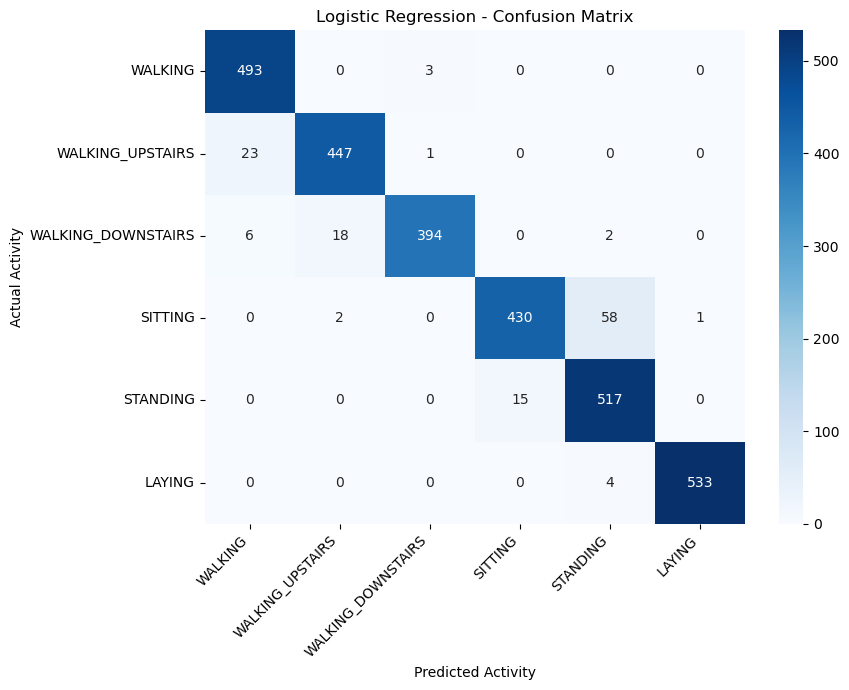

In [44]:
#logistic regression confusion matrix

cm_lr = confusion_matrix(
    y_test,
    predictions["Logistic Regression"]
)


print("Logistic Regression Confusion Matrix:")
print(cm_lr)
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Random Forest Confusion Matrix:
[[484   6   6   0   0   0]
 [ 34 431   6   0   0   0]
 [ 17  43 360   0   0   0]
 [  0   0   0 434  57   0]
 [  0   0   0  39 493   0]
 [  0   0   0   0   0 537]]


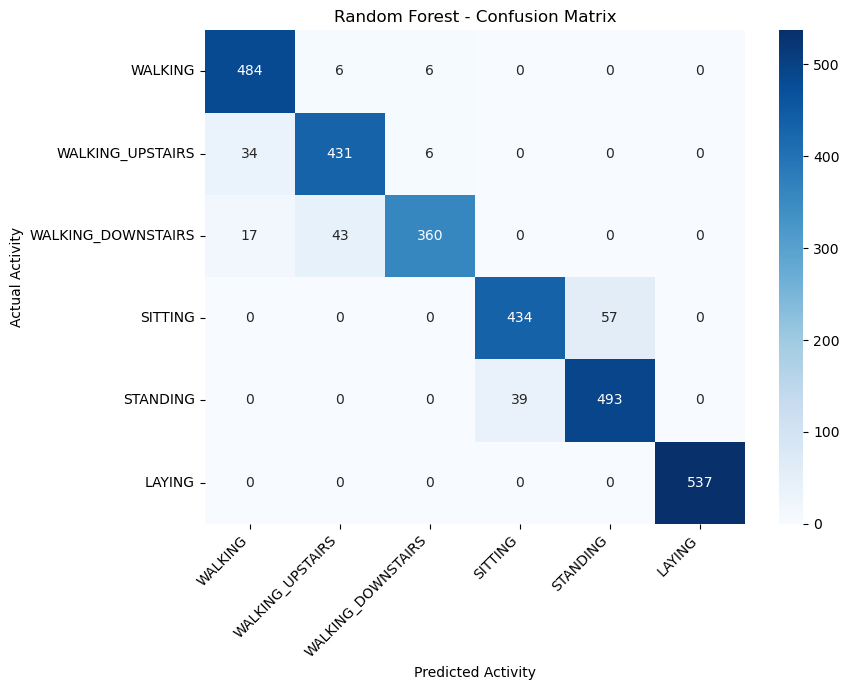

In [45]:
#Random Forest confusion matrix\

cm_rf = confusion_matrix(
    y_test,
    predictions["Random Forest"]
)

print("Random Forest Confusion Matrix:")
print(cm_rf)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


SVM Confusion Matrix:
[[486   6   4   0   0   0]
 [ 15 454   2   0   0   0]
 [  6  25 389   0   0   0]
 [  0   1   0 434  54   2]
 [  0   0   0  17 515   0]
 [  0   0   0   0   0 537]]


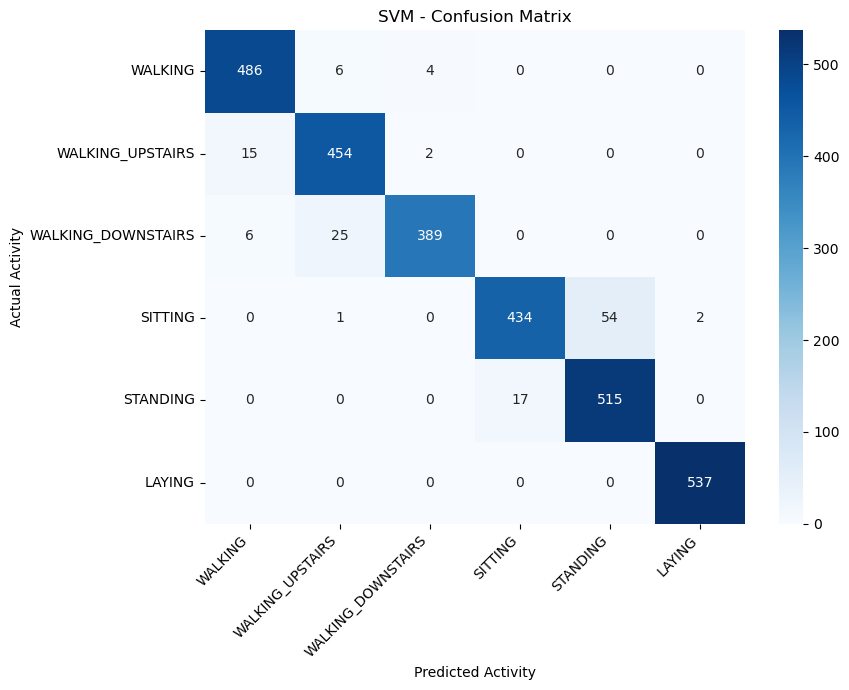

In [46]:
#SVM confusion matrix
cm_svm = confusion_matrix(
    y_test,
    predictions["SVM"]
)

print("SVM Confusion Matrix:")
print(cm_svm)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

KNN Confusion Matrix:
[[486   3   7   0   0   0]
 [ 47 421   3   0   0   0]
 [ 53  48 319   0   0   0]
 [  0   2   0 382 104   3]
 [  0   0   0  26 506   0]
 [  0   0   0  16  10 511]]


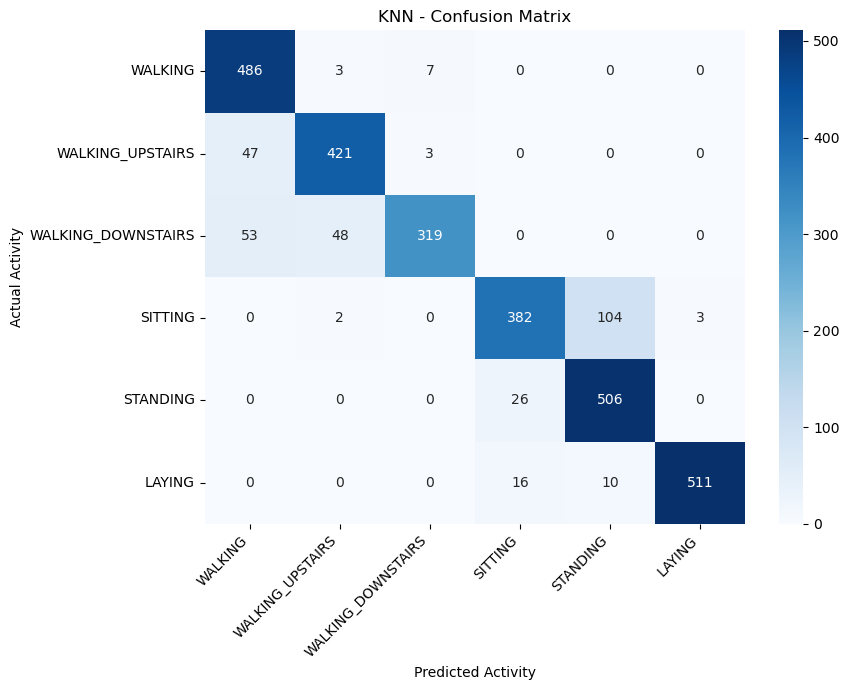

In [47]:
#kNN confusion matrix
cm_knn = confusion_matrix(
    y_test,
    predictions["KNN"]
)

print("KNN Confusion Matrix:")
print(cm_knn)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [48]:
# Save numerical confusion matrices

pd.DataFrame(
    cm_lr,
    index=activity_names,
    columns=activity_names
).to_csv(
    "results/confusion_matrices/logistic_regression_confusion_matrix.csv"
)

pd.DataFrame(
    cm_rf,
    index=activity_names,
    columns=activity_names
).to_csv(
    "results/confusion_matrices/random_forest_confusion_matrix.csv"
)

pd.DataFrame(
    cm_svm,
    index=activity_names,
    columns=activity_names
).to_csv(
    "results/confusion_matrices/svm_confusion_matrix.csv"
)

pd.DataFrame(
    cm_knn,
    index=activity_names,
    columns=activity_names
).to_csv(
    "results/confusion_matrices/knn_confusion_matrix.csv"
)

print("All 4 confusion matrices saved as CSV files!")

All 4 confusion matrices saved as CSV files!


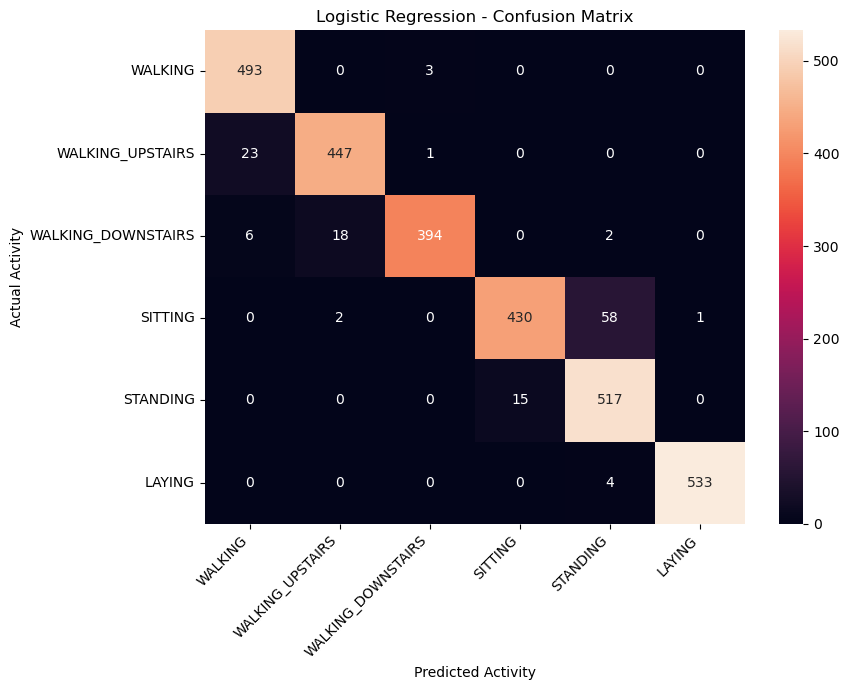

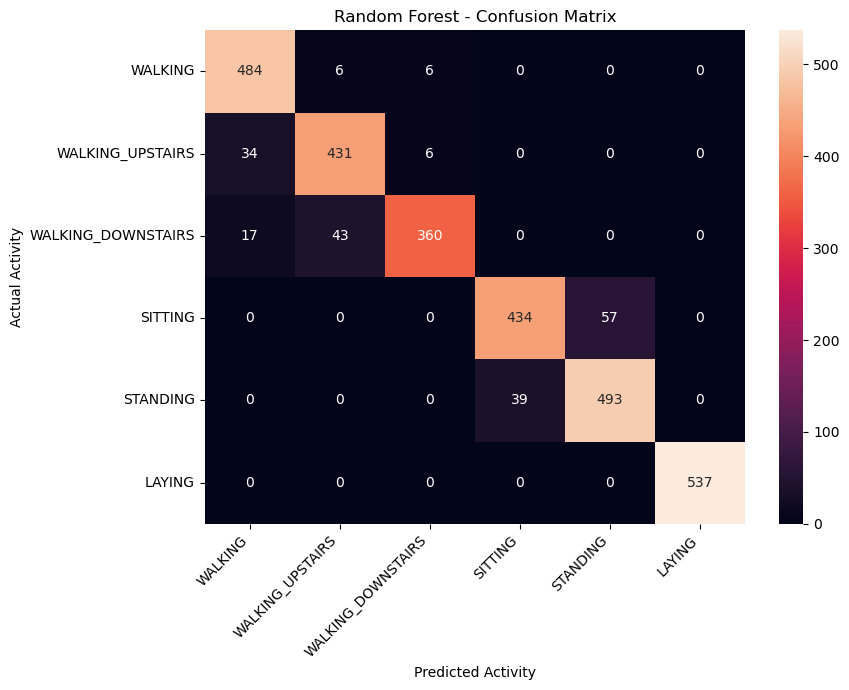

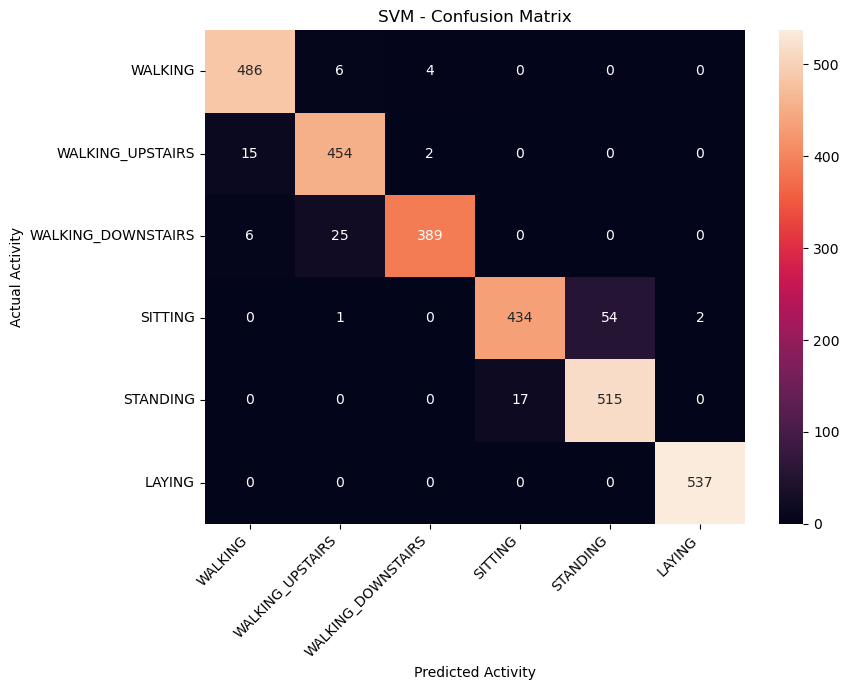

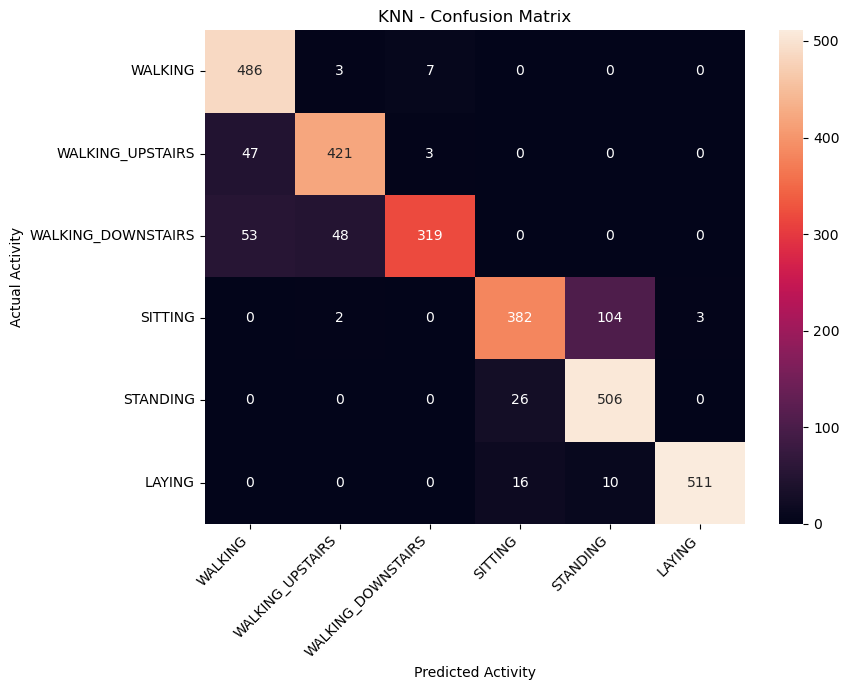

In [50]:
#save images of confusion matrices

#logistic regression confusion matrix
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "results/confusion_matrices/logistic_regression_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#random forest confusion matrix
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "results/confusion_matrices/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#svm confusion matrix
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "results/confusion_matrices/svm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#knn confusion matrix
plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "results/confusion_matrices/knn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
#verify saved confusion matrix images
import os

print("Saved confusion matrix files:\n")

for file in os.listdir("results/confusion_matrices"):
    print(file)

Saved confusion matrix files:

knn_confusion_matrix.csv
knn_confusion_matrix.png
logistic_regression_confusion_matrix.csv
logistic_regression_confusion_matrix.png
random_forest_confusion_matrix.csv
random_forest_confusion_matrix.png
svm_confusion_matrix.csv
svm_confusion_matrix.png


In [53]:
#ROC-CURVES
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import os

print("ROC curve libraries imported successfully!")

y_test_binary = label_binarize(
    y_test,
    classes=[1, 2, 3, 4, 5, 6]
)

print("Binarized test labels shape:", y_test_binary.shape)

ROC curve libraries imported successfully!
Binarized test labels shape: (2947, 6)


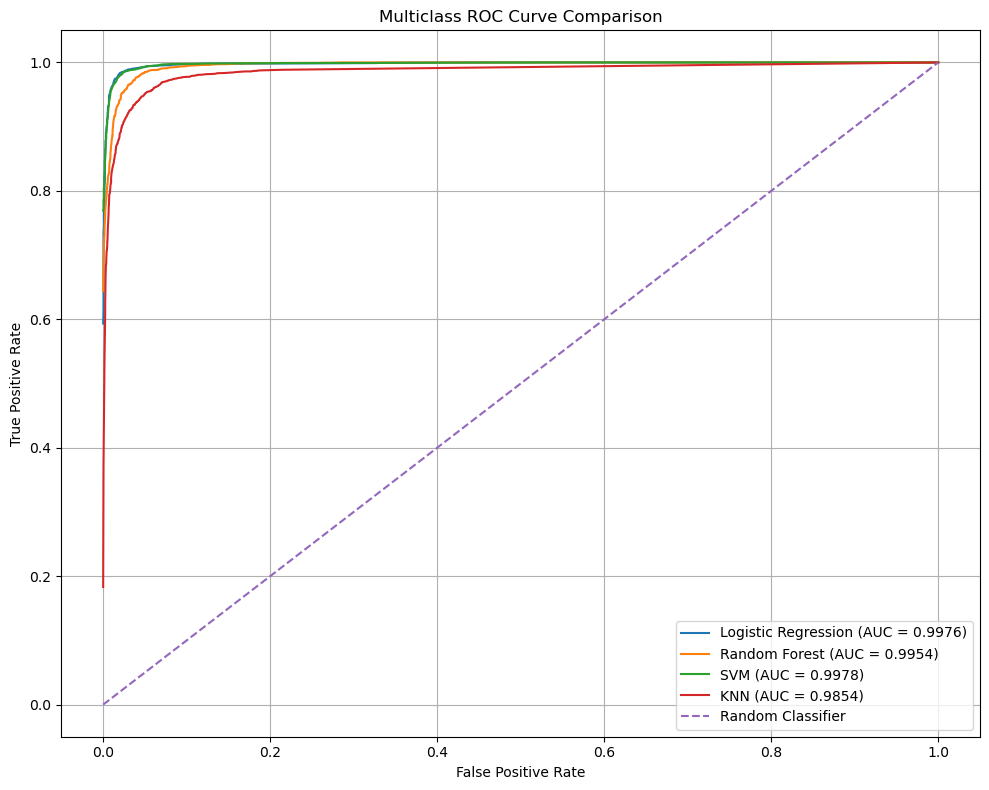

ROC curve comparison saved successfully!


In [ ]:
#ROC-CURVES AND SAVE IMAGE

plt.figure(figsize=(10, 8))

for name in models:

    proba = probabilities[name]

    fpr = {}
    tpr = {}

    for i in range(6):
        fpr[i], tpr[i], _ = roc_curve(
            y_test_binary[:, i],
            proba[:, i]
        )

    all_fpr = np.unique(
        np.concatenate(
            [fpr[i] for i in range(6)]
        )
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(6):
        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= 6

    roc_auc = auc(
        all_fpr,
        mean_tpr
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        label=f"{name} (AUC = {roc_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "results/roc_curves/roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC curve comparison saved successfully!")

In [57]:
#CLASSIFICATION REPORT OF LOGISTIC REGRESSION
report_lr = classification_report(
    y_test,
    predictions["Logistic Regression"],
    target_names=activity_names,
    output_dict=True
)

report_lr_df = pd.DataFrame(report_lr).transpose()

print("Logistic Regression Classification Report")
display(report_lr_df)

Logistic Regression Classification Report


,precision,recall,f1-score,support
WALKING,0.944444,0.993952,0.968566,496.000000
WALKING_UPSTAIRS,0.957173,0.949045,0.953092,471.000000
WALKING_DOWNSTAIRS,0.989950,0.938095,0.963325,420.000000
SITTING,0.966292,0.875764,0.918803,491.000000
STANDING,0.889845,0.971805,0.929021,532.000000
LAYING,0.998127,0.992551,0.995331,537.000000
accuracy,0.954869,0.954869,0.954869,0.954869
macro avg,0.957639,0.953535,0.954690,2947.000000
weighted avg,0.956530,0.954869,0.954793,2947.000000


In [58]:
#Classification report of Random Forest
report_rf = classification_report(
    y_test,
    predictions["Random Forest"],
    target_names=activity_names,
    output_dict=True
)

report_rf_df = pd.DataFrame(report_rf).transpose()

print("Random Forest Classification Report")
display(report_rf_df)

Random Forest Classification Report


,precision,recall,f1-score,support
WALKING,0.904673,0.975806,0.938894,496.00000
WALKING_UPSTAIRS,0.897917,0.915074,0.906414,471.00000
WALKING_DOWNSTAIRS,0.967742,0.857143,0.909091,420.00000
SITTING,0.917548,0.883910,0.900415,491.00000
STANDING,0.896364,0.926692,0.911275,532.00000
LAYING,1.000000,1.000000,1.000000,537.00000
accuracy,0.929420,0.929420,0.929420,0.92942
macro avg,0.930707,0.926438,0.927682,2947.00000
weighted avg,0.930597,0.929420,0.929193,2947.00000


In [59]:
#Classification report of SVM
report_svm = classification_report(
    y_test,
    predictions["SVM"],
    target_names=activity_names,
    output_dict=True
)

report_svm_df = pd.DataFrame(report_svm).transpose()

print("SVM Classification Report")
display(report_svm_df)

SVM Classification Report


,precision,recall,f1-score,support
WALKING,0.958580,0.979839,0.969093,496.000000
WALKING_UPSTAIRS,0.934156,0.963907,0.948798,471.000000
WALKING_DOWNSTAIRS,0.984810,0.926190,0.954601,420.000000
SITTING,0.962306,0.883910,0.921444,491.000000
STANDING,0.905097,0.968045,0.935513,532.000000
LAYING,0.996289,1.000000,0.998141,537.000000
accuracy,0.955209,0.955209,0.955209,0.955209
macro avg,0.956873,0.953649,0.954598,2947.000000
weighted avg,0.956252,0.955209,0.955076,2947.000000


In [60]:
#Classification report of KNN
report_knn = classification_report(
    y_test,
    predictions["KNN"],
    target_names=activity_names,
    output_dict=True
)

report_knn_df = pd.DataFrame(report_knn).transpose()

print("KNN Classification Report")
display(report_knn_df)

KNN Classification Report


,precision,recall,f1-score,support
WALKING,0.829352,0.979839,0.898336,496.000000
WALKING_UPSTAIRS,0.888186,0.893843,0.891005,471.000000
WALKING_DOWNSTAIRS,0.969605,0.759524,0.851802,420.000000
SITTING,0.900943,0.778004,0.834973,491.000000
STANDING,0.816129,0.951128,0.878472,532.000000
LAYING,0.994163,0.951583,0.972407,537.000000
accuracy,0.890736,0.890736,0.890736,0.890736
macro avg,0.899730,0.885653,0.887833,2947.000000
weighted avg,0.898316,0.890736,0.889887,2947.000000


In [62]:
#SAVE ALL REPORTS TO CSV FILES
import os

os.makedirs(
    "results/classification_reports",
    exist_ok=True
)

report_lr_df.to_csv(
    "results/classification_reports/logistic_regression_report.csv"
)

report_rf_df.to_csv(
    "results/classification_reports/random_forest_report.csv"
)

report_svm_df.to_csv(
    "results/classification_reports/svm_report.csv"
)

report_knn_df.to_csv(
    "results/classification_reports/knn_report.csv"
)

print("All 4 classification reports saved successfully!")

All 4 classification reports saved successfully!


In [ ]:
#Compare F1-Scores of all models for each activity class
class_f1_comparison = pd.DataFrame({
    "Logistic Regression": report_lr_df.loc[
        activity_names, "f1-score"
    ],

    "Random Forest": report_rf_df.loc[
        activity_names, "f1-score"
    ],

    "SVM": report_svm_df.loc[
        activity_names, "f1-score"
    ],

    "KNN": report_knn_df.loc[
        activity_names, "f1-score"
    ]
})

class_f1_comparison


Combined classification report saved successfully!


In [67]:
#best model selection based on evaluation metrics
best_model_per_activity = class_f1_comparison.idxmax(axis=1)

best_f1_per_activity = class_f1_comparison.max(axis=1)

activity_winners = pd.DataFrame({
    "Best Model": best_model_per_activity,
    "Best F1-Score": best_f1_per_activity
})

activity_winners["Best F1-Score"] = (
    activity_winners["Best F1-Score"] * 100
).round(2)

activity_winners


,Best Model,Best F1-Score
WALKING,SVM,96.91
WALKING_UPSTAIRS,Logistic Regression,95.31
WALKING_DOWNSTAIRS,Logistic Regression,96.33
SITTING,SVM,92.14
STANDING,SVM,93.55
LAYING,Random Forest,100.00


In [74]:
#Finding the easiest and hardest activities to classify based on F1-Score

class_f1_average = class_f1_comparison.mean(axis=1)

class_f1_average_display = (
    class_f1_average * 100
).round(2)

print("Average F1-Score for each activity:")
display(class_f1_average_display)

#easiest activity based on average F1-Score
easiest_activity = class_f1_average.idxmax()

print("Easiest activity:", easiest_activity)
print(
    f"Average F1-Score: "
    f"{class_f1_average.max() * 100:.2f}%"
)
print()

#hardest activity based on average F1-Score

most_difficult_activity = class_f1_average.idxmin()

print("Most difficult activity:", most_difficult_activity)
print(
    f"Average F1-Score: "
    f"{class_f1_average.min() * 100:.2f}%"
)


Average F1-Score for each activity:


WALKING               94.37
WALKING_UPSTAIRS      92.48
WALKING_DOWNSTAIRS    91.97
SITTING               89.39
STANDING              91.36
LAYING                99.15
dtype: float64

Easiest activity: LAYING
Average F1-Score: 99.15%

Most difficult activity: SITTING
Average F1-Score: 89.39%


In [75]:
# Save the ranking results to a CSV file
class_f1_comparison_display = (
    class_f1_comparison * 100
).round(2)

class_f1_comparison_display.to_csv(
    "results/class_f1_comparison.csv"
)

activity_winners.to_csv(
    "results/activity_winners.csv"
)

print("Class-wise analysis saved successfully!")

Class-wise analysis saved successfully!


In [77]:
#final comparison of all models based on evaluation metrics
final_analysis = pd.DataFrame({
    "Model": [
        "SVM",
        "Logistic Regression",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [95.52, 95.49, 92.94, 89.07],
    "Precision": [95.63, 95.65, 93.06, 89.83],
    "Recall": [95.52, 95.49, 92.94, 89.07],
    "F1-Score": [95.51, 95.48, 92.92, 88.99],
    "AUC-ROC": [99.77, 99.75, 99.56, 98.59]
})

final_analysis.to_csv(
    "results/final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully!")

Final model comparison saved successfully!


## BEST MODEL ACCORDING TO EVALUATION METRICS IS SVM.

In [78]:
#saving best model for future use
import joblib

# Load the already trained SVM
best_model = joblib.load("models/svm.pkl")

# Save SVM as the final selected model
joblib.dump(
    best_model,
    "models/best_model.pkl"
)

print("Best model saved successfully!")
print("Selected model: SVM")

Best model saved successfully!
Selected model: SVM


# MEMBER 3 (SARTHAK JINDAL - 25BCE10189) COMPLETE

## Model Evaluation & Analysis

The four trained machine learning models were evaluated on the unseen test dataset:

1. Logistic Regression
2. Random Forest
3. Support Vector Machine (SVM)
4. K-Nearest Neighbors (KNN)

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- AUC-ROC
- Confusion Matrix
- Classification Reports
- ROC Curve Comparison
- Activity-wise F1-Score Comparison

Prediction and probability dictionaries were generated for all four models.

Final evaluation results:

- Logistic Regression: 95.49% Accuracy, 95.48% F1-Score, 99.75% AUC-ROC
- Random Forest: 92.94% Accuracy, 92.92% F1-Score, 99.56% AUC-ROC
- SVM: 95.52% Accuracy, 95.51% F1-Score, 99.77% AUC-ROC
- KNN: 89.07% Accuracy, 88.99% F1-Score, 98.59% AUC-ROC

Confusion matrices and classification reports were generated and saved separately for all four models. A combined ROC curve was also generated for model comparison.

Activity-wise F1-scores were compared and saved as `class_f1_comparison.csv`. An activity winner table was created to identify the best-performing model for each activity.

The following evaluation files and folders were generated:

```text
results/
├── model_evaluation.csv
├── model_ranking.csv
├── class_f1_comparison.csv
├── activity_winners.csv
│
├── confusion_matrices/
│   ├── logistic_regression_confusion_matrix.csv
│   ├── logistic_regression_confusion_matrix.png
│   ├── random_forest_confusion_matrix.csv
│   ├── random_forest_confusion_matrix.png
│   ├── svm_confusion_matrix.csv
│   ├── svm_confusion_matrix.png
│   ├── knn_confusion_matrix.csv
│   └── knn_confusion_matrix.png
│
├── roc_curves/
│   └── roc_curve_comparison.png
│
└── classification_reports/
    ├── logistic_regression_report.csv
    ├── random_forest_report.csv
    ├── svm_report.csv
    └── knn_report.csv

```
 The complete evaluation workflow was implemented in evaluate_model.py.
 After comparing all four models, SVM was selected as the best overall-performing model and saved as: models/best_model.pkl

# Member 3 work completed successfully.